# Feature Engineering

## Objective

This notebook prepares the selected lead features for machine learning.

The feature audit has already been completed in `01_data_understanding.ipynb`.

The main objectives of this phase are:

1. Clean inconsistent categorical values.
2. Handle missing values appropriately.
3. Handle placeholder values such as `Select`.
4. Group extremely rare categories where appropriate.
5. Prepare binary and numerical features.
6. Create useful business-oriented features where justified.
7. Design a reusable preprocessing pipeline.
8. Ensure that transformations do not introduce data leakage.

### Important Principle

The raw dataset will remain unchanged.

Feature engineering will be performed on a separate working copy, and the final transformations will eventually be implemented inside a reusable scikit-learn preprocessing pipeline.

Import Libraries

In [3]:
# Import Libraries

import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
# Load the raw data set

DATA_PATH = Path("../data/raw/Lead Scoring.csv")

df = pd.read_csv(DATA_PATH)

df.shape

(9240, 37)

In [5]:
# To show first few entries

df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   str    
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   str    
 3   Lead Source                                    9204 non-null   str    
 4   Do Not Email                                   9240 non-null   str    
 5   Do Not Call                                    9240 non-null   str    
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 non-null   

### Condidate feature list

In [7]:
categorical_features = [
    "Lead Origin",
    "Lead Source",
    "Country",
    "Specialization",
    "How did you hear about X Education",
    "What is your current occupation",
    "What matters most to you in choosing a course",
    "Lead Profile",
    "City"
]

binary_features = [
    "Do Not Email",
    "A free copy of Mastering The Interview"
]

numerical_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit"
]

target = "Converted"

In [8]:
candidate_features = (
    categorical_features
    + binary_features
    + numerical_features
)

len(candidate_features), candidate_features

(14,
 ['Lead Origin',
  'Lead Source',
  'Country',
  'Specialization',
  'How did you hear about X Education',
  'What is your current occupation',
  'What matters most to you in choosing a course',
  'Lead Profile',
  'City',
  'Do Not Email',
  'A free copy of Mastering The Interview',
  'TotalVisits',
  'Total Time Spent on Website',
  'Page Views Per Visit'])

### Working Dataset

In [9]:
X = df[candidate_features].copy()
y = df[target].copy()

In [10]:
X.shape, y.shape

((9240, 14), (9240,))

In [11]:
X.head()

,Lead Origin,Lead Source,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Lead Profile,City,Do Not Email,A free copy of Mastering The Interview,TotalVisits,Total Time Spent on Website,Page Views Per Visit
0,API,Olark Chat,NaN,Select,Select,Unemployed,Better Career Prospects,Select,Select,No,No,0.0,0,0.0
1,API,Organic Search,India,Select,Select,Unemployed,Better Career Prospects,Select,Select,No,No,5.0,674,2.5
2,Landing Page Submission,Direct Traffic,India,Business Administration,Select,Student,Better Career Prospects,Potential Lead,Mumbai,No,Yes,2.0,1532,2.0
3,Landing Page Submission,Direct Traffic,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,Select,Mumbai,No,No,1.0,305,1.0
4,Landing Page Submission,Google,India,Select,Other,Unemployed,Better Career Prospects,Select,Mumbai,No,No,2.0,1428,1.0


### Before Transformation Investigate SELECT

In [12]:
select_counts = {}

for column in categorical_features:
    count = (X[column] == "Select").sum()
    if count > 0:
        select_counts[column] = count

select_counts

{'Specialization': np.int64(1942),
 'How did you hear about X Education': np.int64(5043),
 'Lead Profile': np.int64(4146),
 'City': np.int64(2249)}

In [13]:
# To calculate percentage

select_summary = pd.DataFrame(
    {
        "count": select_counts
    }
)

select_summary["percentage"] = (
    select_summary["count"] / len(X) * 100
)

select_summary.sort_values("count", ascending=False)

,count,percentage
How did you hear about X Education,5043,54.577922
Lead Profile,4146,44.870130
City,2249,24.339827
Specialization,1942,21.017316


### Compare Select, NaN, and actual categories

In [14]:
#Compare Select, NaN, and actual categories

for column in categorical_features:
    if (X[column] == "Select").any():
        print("=" * 80)
        print(column)

        analysis = (
            df.groupby(
                df[column].fillna("Missing")
            )["Converted"]
            .agg(["count", "mean"])
        )

        analysis["conversion_rate"] = analysis["mean"] * 100

        print(analysis.sort_values("conversion_rate", ascending=False))

Specialization
                                   count      mean  conversion_rate
Specialization                                                     
Healthcare Management                159  0.496855        49.685535
Banking, Investment And Insurance    338  0.494083        49.408284
Marketing Management                 838  0.486874        48.687351
Operations Management                503  0.473161        47.316103
Human Resource Management            848  0.457547        45.754717
Finance Management                   976  0.446721        44.672131
Business Administration              403  0.444169        44.416873
Supply Chain Management              349  0.432665        43.266476
Rural and Agribusiness                73  0.424658        42.465753
Select                              1942  0.421215        42.121524
Hospitality Management               114  0.421053        42.105263
Media and Advertising                203  0.418719        41.871921
IT Projects Management           

## Handling `Select` and Missing Values

During the categorical feature investigation, four features were found to contain a large number of `"Select"` values:

- `Specialization`
- `How did you hear about X Education`
- `Lead Profile`
- `City`

Initially, it might appear reasonable to treat `"Select"` and `NaN` as the same representation of missing information.

However, conversion analysis shows a substantial difference between the two states:

| Feature | `Select` Conversion | Missing Conversion |
|---|---:|---:|
| `Specialization` | 42.12% | 10.50% |
| `How did you hear about X Education` | 48.21% | 12.82% |
| `Lead Profile` | 40.81% | 13.66% |
| `City` | 49.04% | 10.85% |

The difference is too large to justify combining these categories.

### Decision

We will preserve the distinction between:

- genuine category values
- `"Select"`
- missing (`NaN`)

During feature engineering:

```text
Actual category → preserve
"Select"        → preserve as "Select"
NaN             → replace with "Missing"

### A Category Frequency Audit

In [15]:
category_frequency = {}

for column in categorical_features:
    counts = X[column].value_counts(dropna=False)

    frequency = pd.DataFrame({
        "count": counts,
        "percentage": (counts / len(X) * 100).round(2)
    })

    category_frequency[column] = frequency

    print("=" * 80)
    print(column)
    print(frequency)

Lead Origin
                         count  percentage
Lead Origin                               
Landing Page Submission   4886       52.88
API                       3580       38.74
Lead Add Form              718        7.77
Lead Import                 55        0.60
Quick Add Form               1        0.01
Lead Source
                   count  percentage
Lead Source                         
Google              2868       31.04
Direct Traffic      2543       27.52
Olark Chat          1755       18.99
Organic Search      1154       12.49
Reference            534        5.78
Welingak Website     142        1.54
Referral Sites       125        1.35
Facebook              55        0.60
NaN                   36        0.39
bing                   6        0.06
google                 5        0.05
Click2call             4        0.04
Social Media           2        0.02
Live Chat              2        0.02
Press_Release          2        0.02
blog                   1        0.01
Pay per C

In [16]:
rare_category_summary = []

for column in categorical_features:
    counts = X[column].value_counts(dropna=False)

    for category, count in counts.items():
        percentage = count / len(X) * 100

        if percentage < 1:
            rare_category_summary.append({
                "feature": column,
                "category": category,
                "count": count,
                "percentage": round(percentage, 2)
            })

rare_categories_df = pd.DataFrame(rare_category_summary)

rare_categories_df.sort_values(
    ["feature", "count"]
)

,feature,category,count,percentage
68,City,Tier II Cities,74,0.80
44,Country,Russia,1,0.01
45,Country,Sri Lanka,1,0.01
46,Country,Kenya,1,0.01
47,Country,Tanzania,1,0.01
48,Country,Malaysia,1,0.01
49,Country,Liberia,1,0.01
50,Country,Switzerland,1,0.01
51,Country,Denmark,1,0.01
52,Country,Vietnam,1,0.01


## Rare Category Analysis

The categorical audit shows that several features contain very low-frequency categories.

A single global frequency threshold will not be applied because category frequency must be considered together with:

- business meaning
- statistical reliability
- category consistency
- expected production usage

### Key observations

1. `Lead Source` contains inconsistent representations such as `Google` and `google`. These will first be normalized into a single category.
2. Several Lead Source categories contain only 1–6 observations and will be candidates for grouping into `Other`.
3. `Country` contains many countries with very few observations. Major countries will be retained while extremely rare countries will be consolidated.
4. `Specialization` contains several legitimate educational categories with relatively low frequency. These should not automatically be removed simply because they fall below a numerical frequency threshold.
5. `Occupation` contains very small categories such as `Businessman` and `Housewife`; these are candidates for consolidation into `Other`.
6. `Lead Profile` contains very small categories such as `Lateral Student` and `Dual Specialization Student`. Their high observed conversion rates should be interpreted cautiously because of small sample sizes.
7. Categories such as `Tier II Cities` in `City` may be retained despite relatively low frequency because they have clear business meaning.

### Engineering Principle

Rare-category handling will be performed **inside the preprocessing pipeline**, with category-frequency rules learned from the training data only.

The objective is to reduce unstable sparse categories while preserving meaningful business segments.

Therefore:

> **Rare does not automatically mean irrelevant.**

Category frequency, business meaning, and statistical reliability will be considered together.

## Categorical Value Normalization

Before handling rare categories or encoding, categorical values should be standardized to remove obvious data-entry inconsistencies.

Examples may include:

- leading or trailing whitespace
- inconsistent capitalization
- inconsistent representations of the same category

Normalization should preserve the underlying business meaning of each category.

Important categories such as `Select` and missing values will remain distinct because the feature audit showed that they have substantially different conversion behavior.

In [17]:
for column in categorical_features:
    print("=" * 80)
    print(column)
    
    values = (
        X[column]
        .dropna()
        .astype(str)
        .unique()
    )
    
    for value in sorted(values):
        print(repr(value))

Lead Origin
'API'
'Landing Page Submission'
'Lead Add Form'
'Lead Import'
'Quick Add Form'
Lead Source
'Click2call'
'Direct Traffic'
'Facebook'
'Google'
'Live Chat'
'NC_EDM'
'Olark Chat'
'Organic Search'
'Pay per Click Ads'
'Press_Release'
'Reference'
'Referral Sites'
'Social Media'
'WeLearn'
'Welingak Website'
'bing'
'blog'
'google'
'testone'
'welearnblog_Home'
'youtubechannel'
Country
'Asia/Pacific Region'
'Australia'
'Bahrain'
'Bangladesh'
'Belgium'
'Canada'
'China'
'Denmark'
'France'
'Germany'
'Ghana'
'Hong Kong'
'India'
'Indonesia'
'Italy'
'Kenya'
'Kuwait'
'Liberia'
'Malaysia'
'Netherlands'
'Nigeria'
'Oman'
'Philippines'
'Qatar'
'Russia'
'Saudi Arabia'
'Singapore'
'South Africa'
'Sri Lanka'
'Sweden'
'Switzerland'
'Tanzania'
'Uganda'
'United Arab Emirates'
'United Kingdom'
'United States'
'Vietnam'
'unknown'
Specialization
'Banking, Investment And Insurance'
'Business Administration'
'E-Business'
'E-COMMERCE'
'Finance Management'
'Healthcare Management'
'Hospitality Management'
'Hu

## Categorical Value Normalization

Before handling rare categories or encoding, categorical values should be standardized to remove obvious data-entry inconsistencies.

Examples may include:

- leading or trailing whitespace
- inconsistent capitalization
- inconsistent representations of the same category

Normalization should preserve the underlying business meaning of each category.

Important categories such as `Select` and missing values will remain distinct because the feature audit showed that they have substantially different conversion behavior.

In [18]:
# Create a working copy of the feature set
X_engineered = X.copy()

# Identify categorical features
categorical_features = X_engineered.select_dtypes(
    include="object"
).columns.tolist()

categorical_features

C:\Users\mohsi\AppData\Local\Temp\ipykernel_12752\3391731393.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_engineered.select_dtypes(


['Lead Origin',
 'Lead Source',
 'Country',
 'Specialization',
 'How did you hear about X Education',
 'What is your current occupation',
 'What matters most to you in choosing a course',
 'Lead Profile',
 'City',
 'Do Not Email',
 'A free copy of Mastering The Interview']

In [19]:
def normalize_categorical_values(series):
    """
    Normalize string-based categorical values while preserving
    missing values.
    """
    
    return series.apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

In [20]:
for column in categorical_features:
    X_engineered[column] = normalize_categorical_values(
        X_engineered[column]
    )

In [21]:
# Fix inconsistent categories
X_engineered["Lead Source"] = (
    X_engineered["Lead Source"]
    .replace({
        "google": "Google",
        "bing": "Bing"
    })
)

In [22]:
X_engineered["Lead Source"].value_counts(dropna=False)

Lead Source
Google               2873
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
NaN                    36
Bing                    6
Click2call              4
Social Media            2
Live Chat               2
Press_Release           2
blog                    1
Pay per Click Ads       1
WeLearn                 1
welearnblog_Home        1
youtubechannel          1
testone                 1
NC_EDM                  1
Name: count, dtype: int64

In [23]:
# Feature Engineering Decision Summary

feature_engineering_decisions = {
    
    "Lead Source": {
        "normalize": True,
        "rare_category_grouping": True
    },
    
    "Country": {
        "normalize": True,
        "rare_category_grouping": True
    },
    
    "Specialization": {
        "missing": "Missing",
        "select": "Select"
    }
}

## Rare Category Handling: Lead Source

`Lead Source` contains several acquisition channels with extremely low frequency.

Creating separate model features for categories with only a few observations can produce unstable estimates and unnecessary sparsity.

Therefore, categories with meaningful representation will be retained individually, while extremely rare categories will be consolidated into an `Other` category.

Missing values will remain separate and later be represented as `Missing`.

### Retained Categories

- Google
- Direct Traffic
- Olark Chat
- Organic Search
- Reference
- Welingak Website
- Referral Sites
- Facebook

### Consolidated Categories

All remaining non-missing categories will be grouped into `Other`.

This approach reduces sparse categories while preserving the major acquisition channels.

In [24]:
lead_source_keep = [
    "Google",
    "Direct Traffic",
    "Olark Chat",
    "Organic Search",
    "Reference",
    "Welingak Website",
    "Referral Sites",
    "Facebook"
]

X_engineered["Lead Source"] = X_engineered["Lead Source"].apply(
    lambda x: (
        x
        if pd.isna(x) or x in lead_source_keep
        else "Other"
    )
)

In [25]:
X_engineered["Lead Source"].value_counts(dropna=False)

Lead Source
Google              2873
Direct Traffic      2543
Olark Chat          1755
Organic Search      1154
Reference            534
Welingak Website     142
Referral Sites       125
Facebook              55
NaN                   36
Other                 23
Name: count, dtype: int64

In [26]:
country_counts = (
    X_engineered["Country"]
    .value_counts(dropna=False)
)

country_counts

Country
India                   6492
NaN                     2461
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Bahrain                    7
Hong Kong                  7
Oman                       6
France                     6
unknown                    5
Kuwait                     4
Canada                     4
Nigeria                    4
Germany                    4
South Africa               4
Sweden                     3
Ghana                      2
Belgium                    2
China                      2
Netherlands                2
Asia/Pacific Region        2
Uganda                     2
Italy                      2
Philippines                2
Bangladesh                 2
Russia                     1
Sri Lanka                  1
Kenya                      1
Tanzania                   1
Malaysia                   1
Liberi

In [27]:
country_counts[country_counts >= 10]

Country
India                   6492
NaN                     2461
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Name: count, dtype: int64

## Rare Category Handling: Country

`Country` contains one dominant category and a long tail of countries with very few observations.

Creating separate model features for countries with only a handful of examples may introduce sparse and statistically unstable categories.

Therefore, countries with sufficient representation will be retained individually, while countries with fewer observations will be consolidated into `Other`.

Missing values will remain distinct and later be represented as `Missing`.

### Rule

- Category frequency ≥ 10 → retain individually
- Category frequency < 10 → group into `Other`
- Missing values → preserve for separate missing-value handling

In [28]:
country_counts = X_engineered["Country"].value_counts()

countries_to_keep = country_counts[
    country_counts >= 10
].index

X_engineered["Country"] = X_engineered["Country"].apply(
    lambda x: (
        x
        if pd.isna(x) or x in countries_to_keep
        else "Other"
    )
)

In [29]:
X_engineered["Country"].value_counts(dropna=False)

Country
India                   6492
NaN                     2461
Other                     82
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Name: count, dtype: int64

## Feature Decision: Specialization

`Specialization` represents the educational or professional area of interest of a lead.

Although some specialization categories have relatively low frequency, they represent meaningful and interpretable business segments.

Therefore, rare-category grouping will not be applied to this feature solely based on frequency.

The distinction between `Select` and missing values will also be preserved because the feature audit showed substantially different historical conversion behavior.

### Decision

- Valid specialization categories → Keep
- `Select` → Keep as a separate category
- Missing values → Represent later as `Missing`

In [30]:
X_engineered["Specialization"].value_counts(dropna=False)

Specialization
Select                               1942
NaN                                  1438
Finance Management                    976
Human Resource Management             848
Marketing Management                  838
Operations Management                 503
Business Administration               403
IT Projects Management                366
Supply Chain Management               349
Banking, Investment And Insurance     338
Media and Advertising                 203
Travel and Tourism                    203
International Business                178
Healthcare Management                 159
Hospitality Management                114
E-COMMERCE                            112
Retail Management                     100
Rural and Agribusiness                 73
E-Business                             57
Services Excellence                    40
Name: count, dtype: int64

In [31]:
X_engineered[
    "How did you hear about X Education"
].value_counts(dropna=False)

How did you hear about X Education
Select                   5043
NaN                      2207
Online Search             808
Word Of Mouth             348
Student of SomeSchool     310
Other                     186
Multiple Sources          152
Advertisements             70
Social Media               67
Email                      26
SMS                        23
Name: count, dtype: int64

## Feature Decision: How did you hear about X Education

This feature contains a limited number of meaningful awareness and acquisition categories.

Although `Email` and `SMS` have relatively low frequency, they still represent distinct and interpretable communication channels.

Therefore, additional rare-category grouping will not be applied.

The distinction between `Select` and missing values will be preserved because the feature audit showed substantially different conversion behavior.

### Decision

- Valid categories → Keep
- Existing `Other` category → Keep
- `Select` → Keep as a separate category
- Missing values → Represent later as `Missing`

In [32]:
X_engineered[
    "What is your current occupation"
].value_counts(dropna=False)

What is your current occupation
Unemployed              5600
NaN                     2690
Working Professional     706
Student                  210
Other                     16
Housewife                 10
Businessman                8
Name: count, dtype: int64

## Rare Category Handling: Current Occupation

`What is your current occupation` contains three categories with very small sample sizes:

- Businessman
- Housewife
- Other

These categories contain too few observations to provide reliable category-level patterns when modeled separately.

Therefore, the major occupation categories will be retained individually, while the very small categories will be consolidated into `Other`.

### Retained Categories

- Unemployed
- Working Professional
- Student

### Consolidated Categories

- Businessman
- Housewife
- Other → `Other`

Missing values will remain separate and later be represented as `Missing`.

In [33]:
occupation_keep = [
    "Unemployed",
    "Working Professional",
    "Student"
]

X_engineered["What is your current occupation"] = (
    X_engineered["What is your current occupation"]
    .apply(
        lambda x: (
            x
            if pd.isna(x) or x in occupation_keep
            else "Other"
        )
    )
)

In [34]:
X_engineered[
    "What is your current occupation"
].value_counts(dropna=False)

What is your current occupation
Unemployed              5600
NaN                     2690
Working Professional     706
Student                  210
Other                     34
Name: count, dtype: int64

## Final Decision: What matters most to you in choosing a course

Further feature engineering analysis showed that this feature has extremely limited variation.

Almost all non-missing observations belong to:

- Better Career Prospects

The remaining categories contain only a few observations and cannot provide statistically reliable category-level patterns.

Although the feature was initially retained during the feature audit because of its business relevance, the lack of meaningful variation makes it unlikely to provide stable predictive value.

### Decision

This feature will be removed from the model feature set.

The final model will focus on features that provide stronger and more reliable variation.

In [35]:
feature_to_drop = "What matters most to you in choosing a course"

X_engineered = X_engineered.drop(columns=feature_to_drop)

In [36]:
X_engineered.columns.tolist()

['Lead Origin',
 'Lead Source',
 'Country',
 'Specialization',
 'How did you hear about X Education',
 'What is your current occupation',
 'Lead Profile',
 'City',
 'Do Not Email',
 'A free copy of Mastering The Interview',
 'TotalVisits',
 'Total Time Spent on Website',
 'Page Views Per Visit']

In [37]:
X_engineered["Lead Profile"].value_counts(dropna=False)

Lead Profile
Select                         4146
NaN                            2709
Potential Lead                 1613
Other Leads                     487
Student of SomeSchool           241
Lateral Student                  24
Dual Specialization Student      20
Name: count, dtype: int64

## Rare Category Handling: Lead Profile

`Lead Profile` contains two categories with very small sample sizes:

- Lateral Student
- Dual Specialization Student

Although these categories showed high historical conversion rates, the sample sizes are too small to support reliable category-level estimates.

Therefore, these categories will be consolidated into `Other`.

### Retained Categories

- Select
- Potential Lead
- Other Leads
- Student of SomeSchool

### Consolidated Categories

- Lateral Student
- Dual Specialization Student → Other

Missing values will remain separate and later be represented as `Missing`.

### Production Note

`Lead Profile` is retained for initial model evaluation because it contains strong predictive signal. However, its availability at prediction time must be validated before inclusion in the final production model.

In [38]:
lead_profile_keep = [
    "Select",
    "Potential Lead",
    "Other Leads",
    "Student of SomeSchool"
]

X_engineered["Lead Profile"] = (
    X_engineered["Lead Profile"]
    .apply(
        lambda x: (
            x
            if pd.isna(x) or x in lead_profile_keep
            else "Other"
        )
    )
)

In [39]:
X_engineered["Lead Profile"].value_counts(dropna=False)

Lead Profile
Select                   4146
NaN                      2709
Potential Lead           1613
Other Leads               487
Student of SomeSchool     241
Other                      44
Name: count, dtype: int64

In [40]:
X["City"].value_counts(dropna=False)

City
Mumbai                         3222
Select                         2249
NaN                            1420
Thane & Outskirts               752
Other Cities                    686
Other Cities of Maharashtra     457
Other Metro Cities              380
Tier II Cities                   74
Name: count, dtype: int64

## City Feature Decision

`City` contains a small number of meaningful geographic categories:

- Mumbai
- Thane & Outskirts
- Other Cities
- Other Cities of Maharashtra
- Other Metro Cities
- Tier II Cities
- Select
- Missing

Although `Tier II Cities` contains only 74 observations, it represents a meaningful business segment.

Therefore, no rare-category grouping will be applied to `City`.

### Final Decision

- Preserve all meaningful city categories.
- Preserve `Select` as a separate category.
- Replace missing values with `Missing` during preprocessing.

#  Next Handle binary features


In [41]:
binary_features = [
    "Do Not Email",
    "A free copy of Mastering The Interview"
]

for feature in binary_features:
    print("=" * 80)
    print(feature)
    print(X[feature].value_counts(dropna=False))

Do Not Email
Do Not Email
No     8506
Yes     734
Name: count, dtype: int64
A free copy of Mastering The Interview
A free copy of Mastering The Interview
No     6352
Yes    2888
Name: count, dtype: int64


## Binary Feature Preparation

Two selected features contain binary `Yes` / `No` values:

- `Do Not Email`
- `A free copy of Mastering The Interview`

Both features have complete observations with no missing values.

### Decision

The values will be converted to binary numerical representations:

- `No` → `0`
- `Yes` → `1`

`Do Not Email` will be retained as a communication-preference feature.

`A free copy of Mastering The Interview` will initially be retained and its contribution will be evaluated during model development.

In [42]:
numerical_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit"
]

X[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalVisits,9103.0,3.445238,4.854853,0.0,1.0,3.0,5.0,251.0
Total Time Spent on Website,9240.0,487.698268,548.021466,0.0,12.0,248.0,936.0,2272.0
Page Views Per Visit,9103.0,2.362820,2.161418,0.0,1.0,2.0,3.0,55.0


In [43]:
X[numerical_features].isna().sum()

TotalVisits                    137
Total Time Spent on Website      0
Page Views Per Visit           137
dtype: int64

In [44]:
missing_pattern = X[
    ["TotalVisits", "Page Views Per Visit"]
].isna()

missing_pattern.value_counts()

TotalVisits  Page Views Per Visit
False        False                   9103
True         True                     137
Name: count, dtype: int64

In [45]:
missing_engagement = X[
    X["TotalVisits"].isna()
][
    [
        "TotalVisits",
        "Total Time Spent on Website",
        "Page Views Per Visit"
    ]
]

missing_engagement.describe()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,0.0,137.000000,0.0
mean,NaN,909.503650,NaN
std,NaN,580.354723,NaN
min,NaN,11.000000,NaN
25%,NaN,341.000000,NaN
50%,NaN,1010.000000,NaN
75%,NaN,1413.000000,NaN
max,NaN,2217.000000,NaN


In [46]:
missing_engagement.head(10)

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
77,NaN,1096,NaN
79,NaN,705,NaN
81,NaN,346,NaN
88,NaN,1007,NaN
120,NaN,1111,NaN
133,NaN,986,NaN
134,NaN,889,NaN
177,NaN,1240,NaN
179,NaN,458,NaN
180,NaN,1060,NaN


In [47]:
for feature in ["TotalVisits", "Page Views Per Visit"]:
    
    result = (
        pd.DataFrame({
            "missing": X[feature].isna(),
            "Converted": y
        })
        .groupby("missing")["Converted"]
        .agg(["count", "mean"])
    )
    
    result["conversion_rate"] = result["mean"] * 100
    
    print("=" * 80)
    print(feature)
    print(result)
    

TotalVisits
         count      mean  conversion_rate
missing                                  
False     9103  0.380204        38.020433
True       137  0.729927        72.992701
Page Views Per Visit
         count      mean  conversion_rate
missing                                  
False     9103  0.380204        38.020433
True       137  0.729927        72.992701


## Numerical Missing-Value Analysis

`TotalVisits` and `Page Views Per Visit` each contain 137 missing values.

Further analysis showed that the missing values occur in exactly the same leads:

- Both values recorded: 9,103 leads
- Both values missing: 137 leads
- Mixed missingness pattern: 0 leads

However, these leads can still have substantial positive values for `Total Time Spent on Website`.

Therefore, missing values in these features do not represent zero website engagement.

### Missingness Predictive Signal

The conversion rate differs substantially between the two groups:

| Engagement Metric Status | Leads | Conversion Rate |
|---|---:|---:|
| Metrics recorded | 9,103 | 38.02% |
| Metrics missing | 137 | 72.99% |

This suggests that the shared missingness pattern may contain useful predictive information.

### Final Decision

A single shared missingness indicator will be created:

`Engagement Metrics Missing`

- `0` → `TotalVisits` and `Page Views Per Visit` are recorded
- `1` → both features are missing

The numerical values themselves will be imputed using a strategy learned from the training data only, initially using median imputation.

The preprocessing pipeline will learn the median values from the training data and apply them consistently to validation, test, and future production data.

In [48]:
X[numerical_features].skew()

TotalVisits                    19.911657
Total Time Spent on Website     0.956450
Page Views Per Visit            2.871793
dtype: float64

array([[<Axes: title={'center': 'TotalVisits'}>,
        <Axes: title={'center': 'Total Time Spent on Website'}>],
       [<Axes: title={'center': 'Page Views Per Visit'}>, <Axes: >]],
      dtype=object)

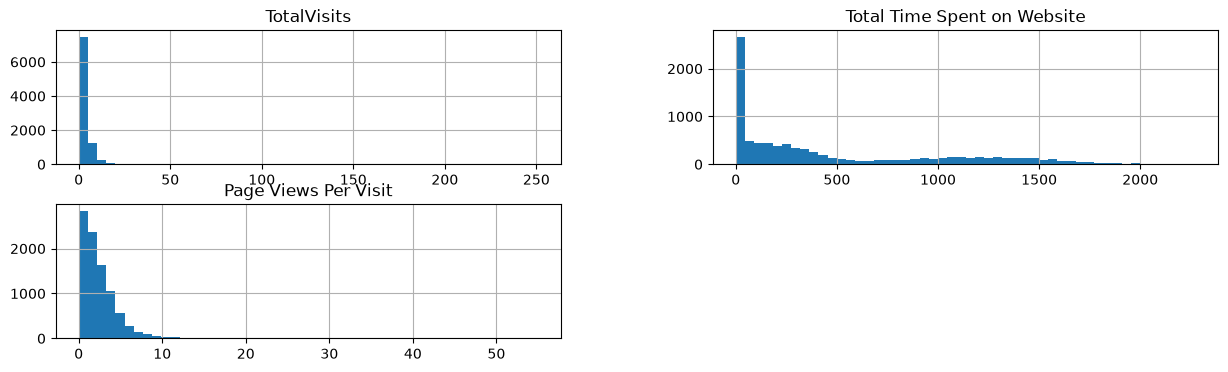

In [49]:
X[numerical_features].hist(figsize=(15, 4), bins=50)

In [50]:
quantiles = X[numerical_features].quantile(
    [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

quantiles

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
0.00,0.0,0.00,0.0
0.01,0.0,0.00,0.0
0.05,0.0,0.00,0.0
0.25,1.0,12.00,1.0
0.50,3.0,248.00,2.0
0.75,5.0,936.00,3.0
0.90,7.0,1380.00,5.0
0.95,10.0,1562.00,6.0
0.99,17.0,1840.61,9.0
1.00,251.0,2272.00,55.0


In [51]:
for feature in ["TotalVisits", "Page Views Per Visit"]:
    
    print("=" * 80)
    print(feature)
    
    for threshold in [10, 17, 20, 30]:
        count = (X[feature] > threshold).sum()
        print(f"Values > {threshold}: {count}")

TotalVisits
Values > 10: 353
Values > 17: 83
Values > 20: 47
Values > 30: 10
Page Views Per Visit
Values > 10: 50
Values > 17: 2
Values > 20: 2
Values > 30: 1


In [52]:
for feature in ["TotalVisits", "Page Views Per Visit"]:
    
    print("=" * 80)
    print(feature)
    
    temp = pd.DataFrame({
        "value": X[feature],
        "Converted": y
    })
    
    temp["group"] = pd.cut(
        temp["value"],
        bins=[-np.inf, 3, 5, 10, 20, np.inf],
        labels=["Low", "Moderate", "High", "Very High", "Extreme"]
    )
    
    print(
        temp.groupby("group", observed=True)["Converted"]
        .agg(["count", "mean"])
        .assign(conversion_rate=lambda x: x["mean"] * 100)
    )

TotalVisits
           count      mean  conversion_rate
group                                      
Low         5570  0.358887        35.888689
Moderate    1903  0.401471        40.147136
High        1277  0.417384        41.738449
Very High    306  0.473856        47.385621
Extreme       47  0.425532        42.553191
Page Views Per Visit
           count      mean  conversion_rate
group                                      
Low         6832  0.375439        37.543911
Moderate    1637  0.403787        40.378742
High         584  0.369863        36.986301
Very High     48  0.375000        37.500000
Extreme        2  0.500000        50.000000


## Website Engagement Missingness Feature

`TotalVisits` and `Page Views Per Visit` are missing for the same group of leads.

The missingness is strongly associated with conversion, with leads missing these engagement values showing a substantially higher conversion rate.

Therefore, missingness itself may contain useful business information.

We will create a binary indicator that preserves this information while allowing the original numerical features to be imputed later inside the preprocessing pipeline.

In [53]:
# Create missingness indicator for website engagement data

X["Website_Engagement_Missing"] = (
    X["TotalVisits"].isna() &
    X["Page Views Per Visit"].isna()
).astype(int)

In [54]:
X["Website_Engagement_Missing"].value_counts()

Website_Engagement_Missing
0    9103
1     137
Name: count, dtype: int64

In [55]:
missingness_analysis = pd.DataFrame({
    "count": X.groupby("Website_Engagement_Missing").size(),
    "conversion_rate": y.groupby(
        X["Website_Engagement_Missing"]
    ).mean() * 100
})

missingness_analysis

,count,conversion_rate
Website_Engagement_Missing,,
0,9103,38.020433
1,137,72.992701


## Final Feature Groups

After categorical cleaning and numerical investigation, we can now organize the candidate features into groups for preprocessing.

Categorical features will be handled using categorical preprocessing.

Numerical features will be imputed and scaled where required.

The engineered website engagement missingness indicator will be treated as a binary numerical feature.

In [56]:
categorical_features = [
    "Lead Origin",
    "Lead Source",
    "Country",
    "Specialization",
    "How did you hear about X Education",
    "What is your current occupation",
    "What matters most to you in choosing a course",
    "Lead Profile",
    "City",
    "Do Not Email",
    "A free copy of Mastering The Interview"
]

numerical_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit"
]

binary_features = [
    "Website_Engagement_Missing"
]

In [57]:
print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Binary features:", len(binary_features))

print("\nTotal model features:", 
      len(categorical_features) +
      len(numerical_features) +
      len(binary_features))

Categorical features: 11
Numerical features: 3
Binary features: 1

Total model features: 15
